# OAKG AAAI 2027 — Experiment Driver

**Observability-Aware Knowledge Graph Reasoning for Heterogeneous Medical Imaging Data**

This notebook is a *thin driver*. All logic lives in the importable `oakg` package under
[`src/oakg/`](../src/oakg/) so every table and figure is reproducible without hidden notebook state.

- Demo mode (default) runs the full pipeline on a reproducible synthetic benchmark.
- Real mode: set `use_demo_data=False` and place the five benchmark CSVs in `data/`.

Deliverables are written under `results/` exactly as listed in Section 13 of the guidelines.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))  # make `oakg` importable

import pandas as pd
import oakg
from oakg import Config
from oakg.pipeline import run_all
print('oakg', oakg.__version__)


oakg 0.1.0


## 1. Configuration

Everything experiment-defining (seeds, thresholds, paths, bootstrap count) is fixed in `Config`
and archived to `results/config.json`. Switch to the real benchmark by editing this one object.


In [2]:
ROOT = pathlib.Path.cwd().parent  # repository root (notebook lives in notebooks/)
config = Config(
    use_demo_data=True,     # set False and fill data/ with the five CSVs for the real study
    n_demo_cases=120,
    seed=2027,
    data_dir=ROOT / 'data',
    results_dir=ROOT / 'results_demo',  # demo only; real results/ untouched
    embeddings_dir=ROOT / 'embeddings',
)
config.to_dict()


{'seed': 2027,
 'top_k': 10,
 'organs': ['liver', 'pancreas', 'spleen', 'left_kidney', 'right_kidney'],
 'use_demo_data': True,
 'n_demo_cases': 120,
 'run_wl_baseline': True,
 'run_neural_baselines': False,
 'n_bootstrap': 500,
 'data_dir': '/home/ud3d4/Desktop/SWOG-OAKG/data',
 'results_dir': '/home/ud3d4/Desktop/SWOG-OAKG/results_demo',
 'embeddings_dir': '/home/ud3d4/Desktop/SWOG-OAKG/embeddings'}

## 2. Run the full pipeline

Regenerates every deliverable: query-level results, summaries, upstream degradation, ranking-policy
selection, risk–coverage curve + figure, ranking consistency, structured-query semantics, and the
publication-ready table with bootstrap CIs.


In [3]:
out = run_all(config)
print('query-level rows:', out.results.shape[0])
print('methods x strata summarized:', out.summary.shape[0])


query-level rows: 8470
methods x strata summarized: 242


## 3. Retrieval summary (Tables A/B)


In [4]:
(out.summary.sort_values('nDCG@10', ascending=False)
    [['track','masking_regime','method','P@10','R@10','nDCG@10','ServedRate']]
    .head(15))


,track,masking_regime,method,P@10,R@10,nDCG@10,ServedRate
128,ref,asymmetric,OAKG-threshold [ref],0.320000,0.691006,0.626448,1.0
7,pred,asymmetric,OAKG-threshold [pred],0.325714,0.711146,0.609080,1.0
172,ref,dataset_style,OAKG-threshold [ref],0.454286,0.399608,0.516712,1.0
238,ref,uniform,OAKG-threshold [ref],0.454286,0.399608,0.516712,1.0
53,pred,dataset_style,WL+Obs [pred],0.471429,0.186701,0.508663,1.0
52,pred,dataset_style,WL [pred],0.471429,0.166976,0.508663,1.0
119,pred,uniform,WL+Obs [pred],0.471429,0.186701,0.508663,1.0
118,pred,uniform,WL [pred],0.471429,0.166976,0.508663,1.0
173,ref,dataset_style,WL [ref],0.460000,0.158631,0.507517,1.0
174,ref,dataset_style,WL+Obs [ref],0.460000,0.178794,0.507517,1.0


## 4. Ranking-policy selection (Table C)

Primary policy chosen by validation nDCG@10 together with served-query rate. Confirm on the real
validation partition and freeze before test evaluation. Earlier results used `gamma*S` (product).


In [5]:
out.policy_selection


,method,mean_metric,served_rate,n_queries
1,OAKG-product [ref],0.438402,1.0,35
0,OAKG-lexicographic [ref],0.429056,1.0,35
2,OAKG-similarity [ref],0.414462,1.0,35
3,OAKG-threshold [ref],0.412791,1.0,35


## 5. Critical paper comparison — OAKG vs. masked cosine

Paired 95% bootstrap CI with Holm correction: does the graph-based observability mechanism add
value beyond pairwise feature masking?


In [6]:
from oakg import comparison_family
subset = out.results[(out.results['track']=='ref') & (out.results['masking_regime']=='random')]
cmp = comparison_family(
    subset, 'OAKG-product [ref]',
    ['Masked cosine [ref]', 'Missingness indicators [ref]', 'Gower [ref]'],
    n_bootstrap=config.n_bootstrap, seed=config.seed,
)
cmp


,n,difference,ci_low,ci_high,p,target,baseline,metric,p_holm
0,35,0.071086,-0.011537,0.154467,0.108,OAKG-product [ref],Masked cosine [ref],nDCG@10,0.324
1,35,0.021311,-0.048741,0.102145,0.580,OAKG-product [ref],Missingness indicators [ref],nDCG@10,0.600
2,35,0.036752,-0.032244,0.101561,0.300,OAKG-product [ref],Gower [ref],nDCG@10,0.600


## 6. Structured-query semantics (Table F)

Closed-world vs. generic open-world vs. OAKG support-aware three-valued (T/F/U) reasoning.


In [7]:
pd.read_csv(config.tables_dir / 'structured_query_summary.csv')


,track,semantics,precision_T,recall_T,f1_T,precision_F,recall_F,f1_F,precision_U,recall_U,f1_U,macro_F1,indeterminate_rate,unsupported_negative_rate
0,ref,closed_world,1.0,0.309859,0.473118,0.780269,1.000000,0.876574,0.0,0.0,0.0,0.449898,0.00000,0.2
1,ref,oakg,1.0,0.309859,0.473118,1.000000,0.822515,0.902615,0.0,0.0,0.0,0.458578,0.32605,0.0
2,ref,open_world,1.0,0.309859,0.473118,1.000000,0.822515,0.902615,0.0,0.0,0.0,0.458578,0.32605,0.0


## 7. Risk–coverage (Figure 1)


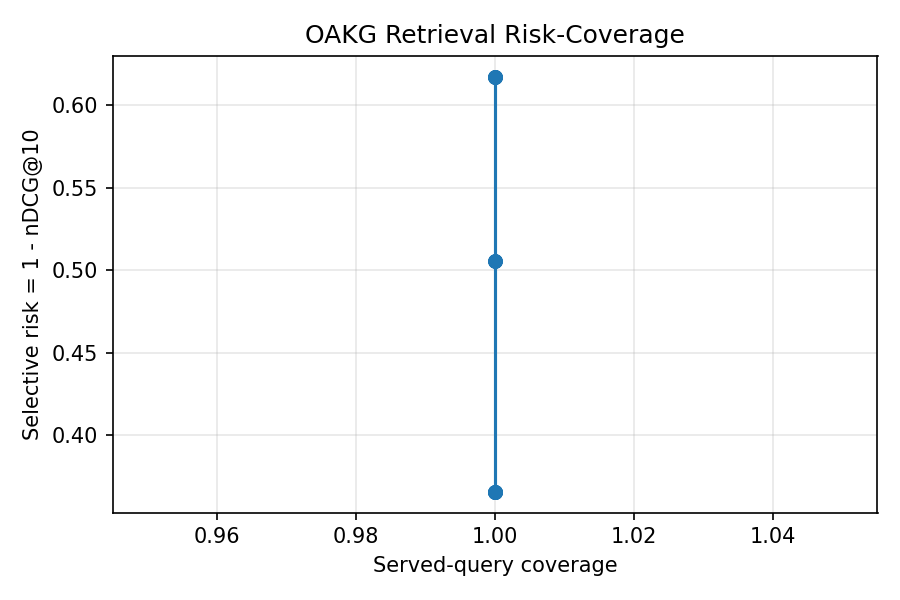

In [8]:
from IPython.display import Image
Image(filename=str(config.figures_dir / 'risk_coverage_curve.png'))


## 8. Deliverables written

See Section 13 of the guidelines. Re-running this notebook regenerates all of them from `config`.


In [9]:
for p in sorted(config.results_dir.rglob('*')):
    if p.is_file() and p.name != '.gitkeep':
        print(' -', p.relative_to(config.results_dir))


 - config.json
 - figures/masking_stress.png
 - figures/risk_coverage_curve.png
 - query_level/query_level_retrieval_results.csv
 - query_level/structured_query_predictions.csv
 - tables/cross_backbone_observability.csv
 - tables/publication_ready_retrieval_table.csv
 - tables/query_diagnostics.csv
 - tables/ranking_consistency.csv
 - tables/ranking_policy_selection.csv
 - tables/retrieval_summary.csv
 - tables/risk_coverage_curve.csv
 - tables/structured_query_summary.csv
 - tables/upstream_degradation.csv
